# Purpose

Investigate newly measured 405 nm spectrum for MR1 Visitech optical engine. 405 nm LED installed in optical engine the week of August 8, 2022.

# Imports

In [1]:
import copy
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

from scipy.interpolate import interp1d
import scipy
print(scipy.__version__)

import resin_spectral_analysis.data as data
from resin_spectral_analysis.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from resin_spectral_analysis.irradiance import Irradiance
from resin_spectral_analysis.utilities import ArrayParams, find_index_of_nearest, find_index_of_max, shift, shift_peak_wavelength
from resin_spectral_analysis.normalizeddose import NormalizedDose
from resin_spectral_analysis.sourcespectrum import SourceSpectrum

1.8.1


In [2]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50abcca0>,
 'Asiga_405nm_100um_fiber-2016-12-14': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50abcdf0>,
 'HR1_385nm_100um_fiber-2016-12-14': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50abcfd0>,
 'HR2_385nm_2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50abcf10>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50abcee0>,
 'HR3.2_365nm_no_filter-2019-12-31': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50abcdc0>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50ad81c0>,
 'HR3.3_365nm_no_filter-2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8a50ad8220>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <resin

# Common variables

In [4]:
wavelengths = np.linspace(*ArrayParams(300, 480, 361))

z_array_params = ArrayParams(0, 100, 201)

# wavelength_array_params=ArrayParams(300, 440, 281)

save_plot_figures = False

# Sources

In [5]:
Asiga_405nm = data.sources['Asiga_405nm_100um_fiber-2016-12-14']
MR1_Visitech_405nm = data.sources['MR1_405nm_Visitech_unfiltered_2022-08-12']
MR1_Wintech_filtered_365nm = data.sources['MR1_365nm_Wintech_370_nm_short_pass_filter_2020-03-25']

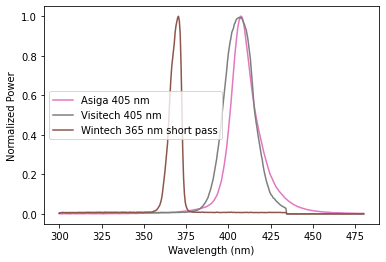

In [13]:
fig, ax = plt.subplots()
ax.plot(wavelengths, Asiga_405nm.calc_power(wavelengths), c='C6', label='Asiga 405 nm')
ax.plot(wavelengths, MR1_Visitech_405nm.calc_power(wavelengths), c='C7', label='Visitech 405 nm')
ax.plot(wavelengths, MR1_Wintech_filtered_365nm.calc_power(wavelengths), c='C5', label='Wintech 365 nm short pass')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Normalized Power')
ax.legend();

# Resins

In [6]:
# Monomer
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)

# Photoinitiator
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

# Resin - Avobenzone 2%, Sudan I 0.6%
avobenzone_2p0 = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    2.0
)
sudanI_0p6 = ResinConstituentAbsorber(
    data.absorbers['sudanI_in_PEGDA_2017-04-13'],
    0.6
)
resin_avo2p0_sud0p6 = Resin(monomers=pegda, absorbers=[avobenzone_2p0, sudanI_0p6], photoinitiators=irgacure819)

# Resin - Avobenzone 1.5%, NPS 3%
avobenzone_1p5 = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    1.5
)
nps_3p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    3.0
)
resin_avo1p5_nps3p0 = Resin(monomers=pegda, absorbers=[avobenzone_1p5, nps_3p0], photoinitiators=irgacure819)


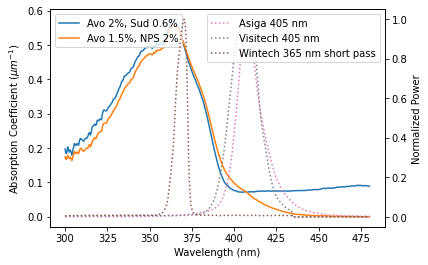

In [7]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_avo2p0_sud0p6.calc_absorption_coef_inv_um(wavelengths), label='Avo 2%, Sud 0.6%')
ax.plot(wavelengths, resin_avo1p5_nps3p0.calc_absorption_coef_inv_um(wavelengths), label='Avo 1.5%, NPS 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, Asiga_405nm.calc_power(wavelengths), c='C6', ls=':', label='Asiga 405 nm')
ax2.plot(wavelengths, MR1_Visitech_405nm.calc_power(wavelengths), c='C7', ls=':', label='Visitech 405 nm')
ax2.plot(wavelengths, MR1_Wintech_filtered_365nm.calc_power(wavelengths), c='C5', ls=':', label='Wintech 365 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');
